<a href="https://colab.research.google.com/github/aiymvr/Youtube_Analysis/blob/main/Youtube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Comparative Analysis of Engagement Dynamics in YouTube Shorts and Long-Form Videos**

**Research Question: How does the time until a YouTube video reaches peak engagement differ between Shorts and long-form content, and how does engagement evolve over time following that peak?**

In [ ]:
!pip install isodate google-api-python-client
import pandas as pd
import numpy as np
import isodate
from googleapiclient.discovery import build
from google.colab import userdata

API_KEY = userdata.get('YOUTUBE_API_KEY')

youtube = build(
    "youtube",
    "v3",
    developerKey=API_KEY
)

### **Data Collection & Preprocessing**

In this research I used Youtube API to collect video IDs by iterating through 16 predefined search queries (such as "gaming," "music," and "coding"), fetching up to 100 video results per query through paginated requests (50 per page), and storing all extracted video IDs in a list for subsequent detailed metadata retrieval.

In [ ]:
search_queries = [
    "gaming",
    "technology",
    "education",
    "music",
    "podcast",
    "sports",
    "news",
    "entertainment",
    "science",
    "movies",
    "finance",
    "tutorial",
    "travel",
    "fitness",
    "food",
    "coding"
]

video_ids = []

VIDEOS_PER_QUERY = 100

for query in search_queries:

    next_page_token = None

    collected = 0

    while collected < VIDEOS_PER_QUERY:

        request = youtube.search().list(
            q=query,
            part="snippet",
            type="video",
            maxResults=50,
            pageToken=next_page_token
        )

        response = request.execute()

        for item in response["items"]:

            video_ids.append(item["id"]["videoId"])

        collected += len(response["items"])

        next_page_token = response.get("nextPageToken")

        if not next_page_token:
            break

print("Collected Video IDs:", len(video_ids))

Collected Video IDs: 1696


Removing duplicates

In [ ]:
video_ids = list(set(video_ids))

print("Unique video IDs:", len(video_ids))

Unique video IDs: 1600


Getting video details

In [ ]:
all_data = []

# API allows max 50 IDs per request
for i in range(0, len(video_ids), 50):

    batch_ids = video_ids[i:i+50]

    request = youtube.videos().list(
        part="snippet,statistics,contentDetails",
        id=",".join(batch_ids)
    )

    response = request.execute()

    for item in response["items"]:

        try:

            title = item["snippet"]["title"]
            channel = item["snippet"]["channelTitle"]
            published_at = item["snippet"]["publishedAt"]
            category_id = item["snippet"]["categoryId"]

            duration = item["contentDetails"]["duration"]

            duration_seconds = int(
                isodate.parse_duration(duration).total_seconds()
            )


            if duration_seconds <= 60:
                video_type = "Short"
            else:
                video_type = "Long"


            views = int(item["statistics"].get("viewCount", 0))
            likes = int(item["statistics"].get("likeCount", 0))
            comments = int(item["statistics"].get("commentCount", 0))


            all_data.append({
                "title": title,
                "channel": channel,
                "published_at": published_at,
                "category_id": category_id,
                "duration_seconds": duration_seconds,
                "video_type": video_type,
                "views": views,
                "likes": likes,
                "comments": comments
            })

        except Exception as e:
            print("Error:", e)

Creating data frame

In [ ]:
df = pd.DataFrame(all_data)

print(df.head())

                                               title  \
0  Dude Perfect takes an at-bat atTexas A&M! #dud...   
1  PODCAST MREŽNICA: Lošo: Guraju rat! Kina i Ira...   
2  the music stopped before they even finished!? ...   
3   5 Easy At Home Science Experiments w/ Mark Rober   
4  PERU: The World’s Strangest Hidden Gem Deep Wi...   

                    channel          published_at category_id  \
0      The Savannah Bananas  2026-05-03T03:23:41Z          17   
1            Radio Mrežnica  2026-05-19T18:00:01Z          25   
2  W.O Kpop (World of KPOP)  2026-05-19T09:00:13Z          24   
3                CrunchLabs  2024-11-23T16:00:35Z          28   
4                TRUE GLOBE  2026-04-04T11:00:50Z          19   

   duration_seconds video_type     views  likes  comments  
0                39      Short    697623  13542       197  
1              6316       Long    142645   4427         0  
2                11      Short   1071231  11133       135  
3               735       Long  

Data cleaning


In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Remove videos with zero views
df = df[df["views"] > 0]

# Reset index
df.reset_index(drop=True, inplace=True)

print("\nDataset Shape:", df.shape)


Dataset Shape: (1592, 9)


In [ ]:
# Convert upload time
df["published_at"] = pd.to_datetime(df["published_at"])

# Upload year/month/day
df["upload_year"] = df["published_at"].dt.year
df["upload_month"] = df["published_at"].dt.month
df["upload_day"] = df["published_at"].dt.day_name()
df["upload_hour"] = df["published_at"].dt.hour

# Engagement metrics

df["like_view_ratio"] = df["likes"] / df["views"]

df["comment_view_ratio"] = (
    df["comments"] / df["views"]
)

df["engagement_rate"] = (
    (df["likes"] + df["comments"]) / df["views"]
)

# Days since upload

current_date = pd.Timestamp.now(tz='UTC')

df["days_since_upload"] = (
    current_date - df["published_at"]
).dt.days

Removing extreme outliers using percentile filtering

In [ ]:
upper_limit = df["views"].quantile(0.99)

df = df[df["views"] <= upper_limit]

print("\nDataset Shape After Outlier Removal:", df.shape)


Dataset Shape After Outlier Removal: (1576, 17)


Data overview

In [ ]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nVideo Type Counts:")
print(df["video_type"].value_counts())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1576 entries, 0 to 1591
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   title               1576 non-null   object             
 1   channel             1576 non-null   object             
 2   published_at        1576 non-null   datetime64[ns, UTC]
 3   category_id         1576 non-null   object             
 4   duration_seconds    1576 non-null   int64              
 5   video_type          1576 non-null   object             
 6   views               1576 non-null   int64              
 7   likes               1576 non-null   int64              
 8   comments            1576 non-null   int64              
 9   upload_year         1576 non-null   int32              
 10  upload_month        1576 non-null   int32              
 11  upload_day          1576 non-null   object             
 12  upload_hour         1576

In [ ]:
df.to_csv("youtube_shorts_vs_long_cleaned.csv", index=False)

In [ ]:
print("\nFinal Dataset Preview:")
print(df.head())


Final Dataset Preview:
                                               title             channel  \
1  I met the most shredded farmer in India🇮🇳 #sho...        Dhanush Amin   
2  Top 5 things to eat near Mulund station #mumba...      Pramod Bathija   
3  TYLA TUTORIAL FOR ALL THE BACON BADDIES💅🏼🔥🙌🏼 #...     Rylen and Chloe   
4  Impossible Places: World's Most Extreme Corner...  New Travel Insight   
5     Craziest "GAME OVER" Moments in Sports History      Highlight Reel   

               published_at category_id  duration_seconds video_type  \
1 2025-04-20 06:15:57+00:00          22                21      Short   
2 2024-05-12 07:59:02+00:00          22                60      Short   
3 2024-11-08 01:19:05+00:00          22                14      Short   
4 2026-03-10 10:48:12+00:00          19              4112       Long   
5 2021-10-16 00:00:07+00:00          17              1275       Long   

      views    likes  comments  upload_year  upload_month upload_day  \
1  34676279  1

In [ ]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       category_id  duration_seconds         views         likes  \
count  1593.000000       1593.000000  1.593000e+03  1.593000e+03   
mean     21.763967       1272.777150  1.140272e+07  2.219738e+05   
std       5.763952       3621.418816  2.931774e+07  6.335276e+05   
min       1.000000          0.000000  2.380000e+02  0.000000e+00   
25%      20.000000         22.000000  8.613500e+04  9.850000e+02   
50%      22.000000         60.000000  1.139126e+06  1.478300e+04   
75%      25.000000        952.000000  8.933533e+06  1.436610e+05   
max      29.000000      43644.000000  2.678412e+08  8.200278e+06   

            comments  upload_year  upload_month  upload_hour  like_view_ratio  \
count    1593.000000  1593.000000   1593.000000  1593.000000      1593.000000   
mean     2259.676711  2024.986817      5.586315    12.105461         0.024655   
std      7478.800979     1.613916      2.545365     5.901105         0.024279   
min         0.000000  2009.000000      1.0

### **Exploratory Data Analysis (EDA)**

In [ ]:
import matplotlib.pyplot as plt

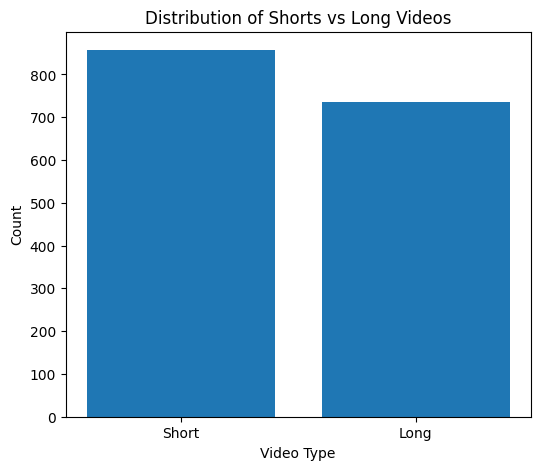

In [ ]:
video_counts = df["video_type"].value_counts()
plt.figure(figsize=(6,5))

plt.bar(video_counts.index, video_counts.values)

plt.title("Distribution of Shorts vs Long Videos")
plt.xlabel("Video Type")
plt.ylabel("Count")

plt.show()

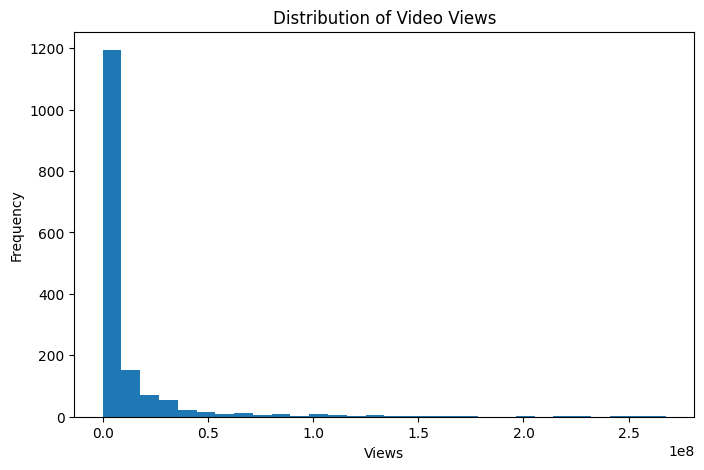

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["views"], bins=30)

plt.title("Distribution of Video Views")
plt.xlabel("Views")
plt.ylabel("Frequency")

plt.show()

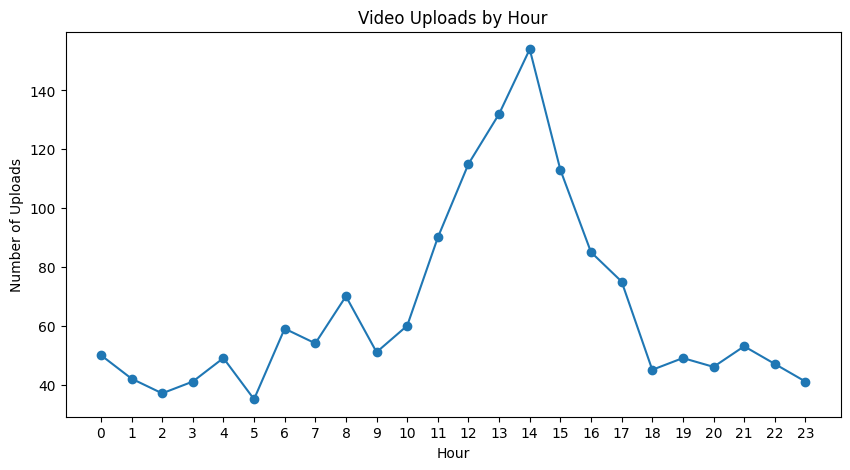

In [ ]:
hourly_uploads = (
    df["upload_hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    hourly_uploads.index,
    hourly_uploads.values,
    marker='o'
)

plt.title("Video Uploads by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Uploads")

plt.xticks(range(0,24))

plt.show()

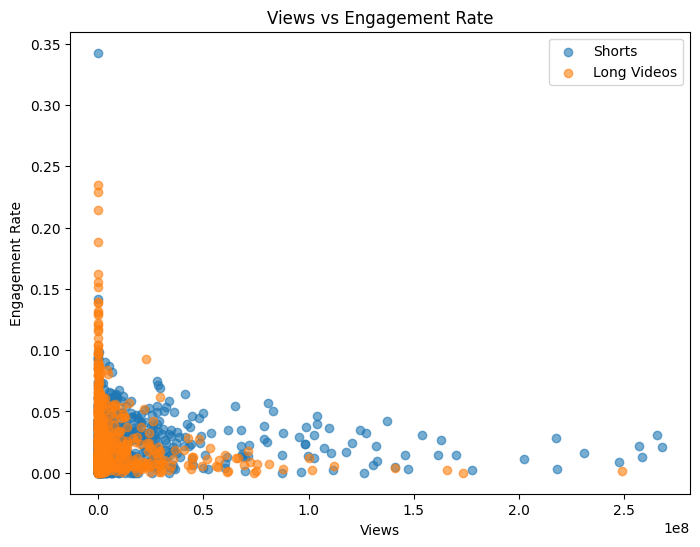

In [ ]:
shorts = df[df["video_type"] == "Short"]
longs = df[df["video_type"] == "Long"]

plt.figure(figsize=(8,6))

plt.scatter(
    shorts["views"],
    shorts["engagement_rate"],
    alpha=0.6,
    label="Shorts"
)

plt.scatter(
    longs["views"],
    longs["engagement_rate"],
    alpha=0.6,
    label="Long Videos"
)

plt.title("Views vs Engagement Rate")
plt.xlabel("Views")
plt.ylabel("Engagement Rate")

plt.legend()

plt.show()

1. The dataset contains both Shorts and Long videos.
2. View counts are highly skewed, requiring log transformation.
3. Engagement behavior differs between Shorts and Long videos.
4. Some upload hours appear more frequent than others.
5. Likes and comments are strongly correlated with views.
6. Duration may influence engagement dynamics.

### **Bayesian Regression Model**

In [ ]:
import pymc as pm
import arviz as az
df["video_type_encoded"] = (
    df["video_type"] == "Short"
).astype(int)

df["log_views"] = np.log1p(df["views"])

In [ ]:
features = [
    "video_type_encoded",
    "duration_seconds",
    "likes",
    "comments",
    "upload_hour",
    "days_since_upload"
]

X = df[features]

y = df["log_views"]

X_scaled = (X - X.mean()) / X.std()

In [ ]:
with pm.Model() as bayesian_model:

    # PRIORS
    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=10
    )

    beta_video_type = pm.Normal(
        "beta_video_type",
        mu=0,
        sigma=10
    )

    beta_duration = pm.Normal(
        "beta_duration",
        mu=0,
        sigma=10
    )

    beta_likes = pm.Normal(
        "beta_likes",
        mu=0,
        sigma=10
    )

    beta_comments = pm.Normal(
        "beta_comments",
        mu=0,
        sigma=10
    )

    beta_upload_hour = pm.Normal(
        "beta_upload_hour",
        mu=0,
        sigma=10
    )

    beta_days = pm.Normal(
        "beta_days",
        mu=0,
        sigma=10
    )

    # ERROR TERM
    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )

    # REGRESSION EQUATION
    mu = (
        intercept
        + beta_video_type * X_scaled["video_type_encoded"]
        + beta_duration * X_scaled["duration_seconds"]
        + beta_likes * X_scaled["likes"]
        + beta_comments * X_scaled["comments"]
        + beta_upload_hour * X_scaled["upload_hour"]
        + beta_days * X_scaled["days_since_upload"]
    )

    # LIKELIHOOD

    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=y
    )


    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.95,
        return_inferencedata=True
    )

Output()

In [ ]:
summary = az.summary(trace)

print("\nBayesian Regression Summary:\n")
print(summary)


Bayesian Regression Summary:

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
beta_comments      0.263  0.067   0.137    0.385      0.001    0.001   
beta_days          1.135  0.063   1.008    1.245      0.001    0.001   
beta_duration     -0.066  0.062  -0.178    0.050      0.001    0.001   
beta_likes         0.945  0.066   0.822    1.068      0.001    0.001   
beta_upload_hour   0.137  0.061   0.027    0.251      0.001    0.001   
beta_video_type    0.150  0.064   0.024    0.258      0.001    0.001   
intercept         13.578  0.060  13.464   13.692      0.001    0.001   
sigma              2.335  0.041   2.259    2.411      0.001    0.001   

                  ess_bulk  ess_tail  r_hat  
beta_comments       2937.0    2878.0    1.0  
beta_days           3875.0    2664.0    1.0  
beta_duration       5069.0    2925.0    1.0  
beta_likes          4215.0    2989.0    1.0  
beta_upload_hour    4484.0    2667.0    1.0  
beta_video_type     4180.0    3021.0    1.0 

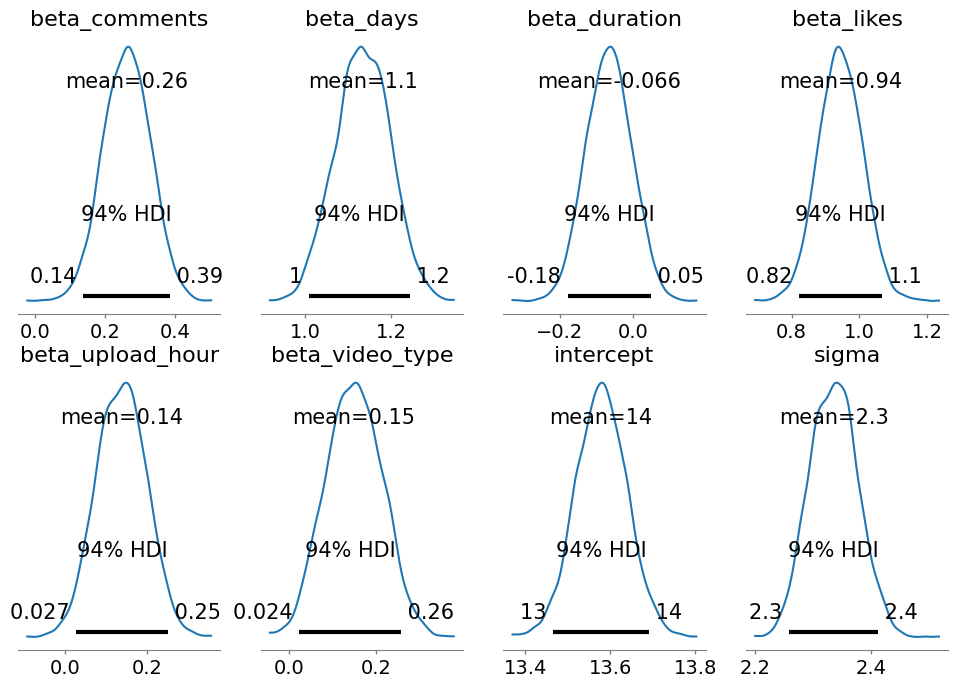

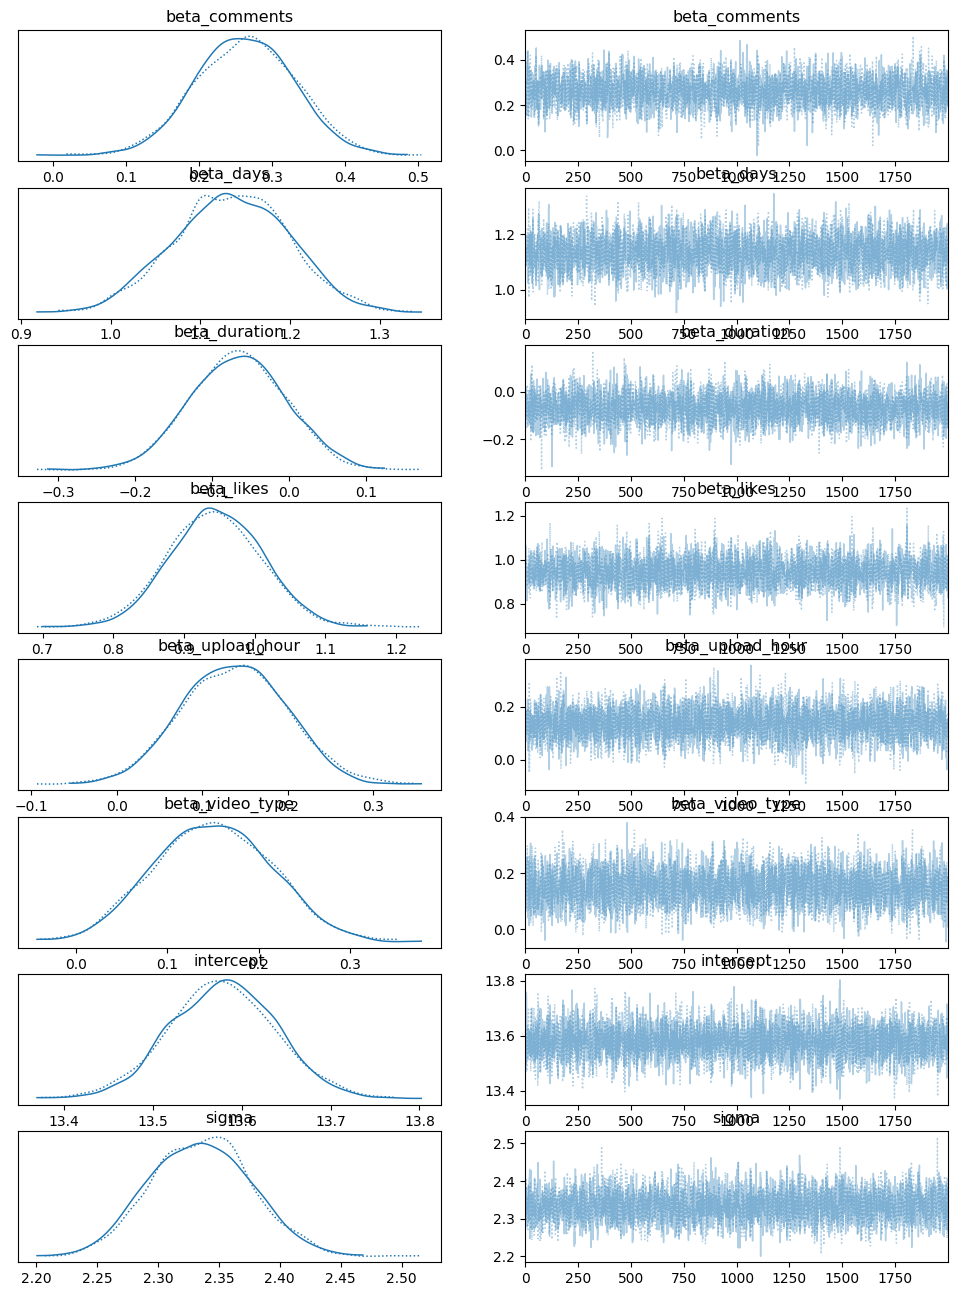


Posterior Means:

beta_video_type: 0.1498
beta_duration: -0.0662
beta_likes: 0.9446
beta_comments: 0.2631
beta_upload_hour: 0.1373
beta_days: 1.1346


In [ ]:

az.plot_posterior(
    trace,
    figsize=(12,8)
)

plt.show()

az.plot_trace(trace)

plt.show()


posterior_means = {
    var: trace.posterior[var].mean().values
    for var in [
        "beta_video_type",
        "beta_duration",
        "beta_likes",
        "beta_comments",
        "beta_upload_hour",
        "beta_days"
    ]
}

print("\nPosterior Means:\n")

for key, value in posterior_means.items():
    print(f"{key}: {value:.4f}")


The Bayesian regression model estimates how video
characteristics influence log-transformed views.

Priors:
- Normal(0,10) priors were used for coefficients.
- This assumes moderate uncertainty and prevents
  unrealistically large effects.

Posterior Analysis:
- Positive coefficients indicate positive influence
  on video views.
- Negative coefficients indicate negative influence.
- Posterior distributions represent updated beliefs
  after observing the data.

Key Variable:
- beta_video_type measures the effect of Shorts
  compared to Long videos.

### **Time Series Analysis**

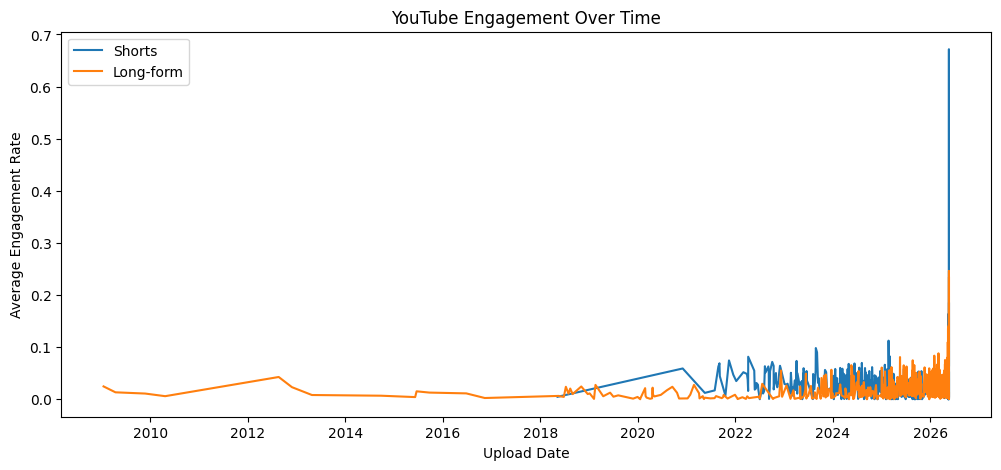

SHORTS ADF TEST
ADF Statistic: -2.8592018777421884
p-value: 0.050302119372035194

LONG-FORM ADF TEST
ADF Statistic: -5.19169459048701
p-value: 9.141918051993856e-06

SHORTS ADF TEST AFTER DIFFERENCING
ADF Statistic: -11.308846180473477
p-value: 1.2535496181199064e-20


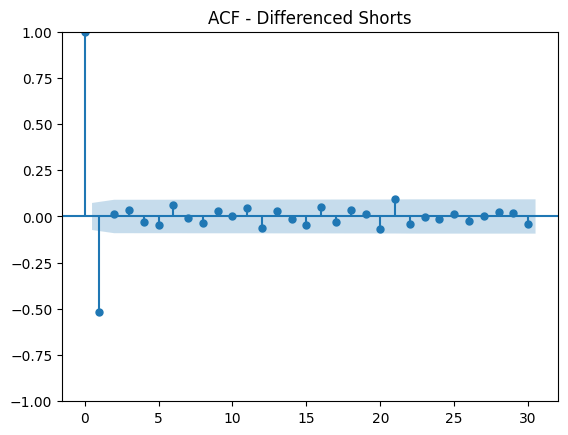

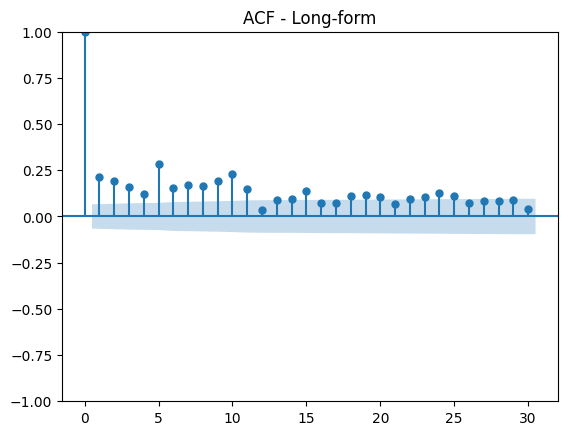

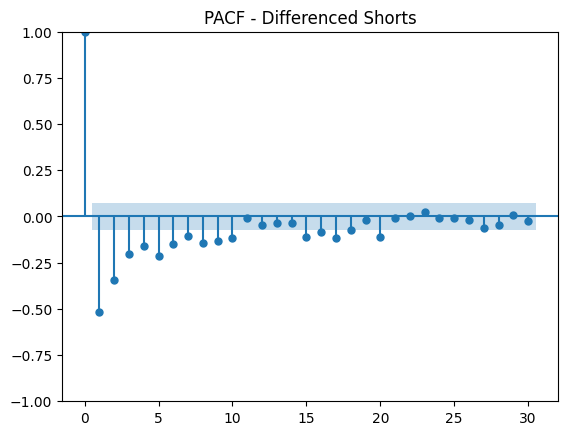

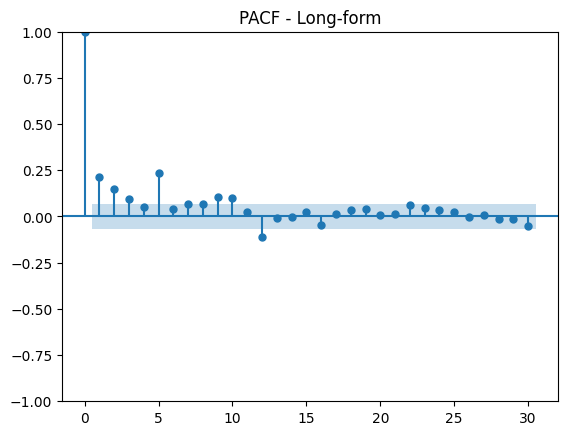

In [ ]:
df = pd.read_csv("youtube_shorts_vs_long_cleaned.csv")
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


df['published_at'] = pd.to_datetime(df['published_at'])
daily_engagement = (
    df.groupby(['published_at', 'video_type'])['engagement_rate']
    .mean()
    .reset_index()
)


shorts = daily_engagement[
    daily_engagement['video_type'] == 'Short'
].set_index('published_at')

longs = daily_engagement[
    daily_engagement['video_type'] == 'Long'
].set_index('published_at')

plt.figure(figsize=(12,5))

plt.plot(
    shorts.index,
    shorts['engagement_rate'],
    label='Shorts'
)

plt.plot(
    longs.index,
    longs['engagement_rate'],
    label='Long-form'
)

plt.xlabel("Upload Date")
plt.ylabel("Average Engagement Rate")
plt.title("YouTube Engagement Over Time")
plt.legend()

plt.show()



print("SHORTS ADF TEST")
result_short = adfuller(
    shorts['engagement_rate'].dropna()
)

print("ADF Statistic:", result_short[0])
print("p-value:", result_short[1])

print("\nLONG-FORM ADF TEST")
result_long = adfuller(
    longs['engagement_rate'].dropna()
)

print("ADF Statistic:", result_long[0])
print("p-value:", result_long[1])

# Interpretation:
# p < 0.05 → stationary
# p > 0.05 → non-stationary

# =============================
# DIFFERENCING FOR SHORTS
# =============================

shorts_diff = shorts['engagement_rate'].diff().dropna()

# ADF test after differencing
print("\nSHORTS ADF TEST AFTER DIFFERENCING")

result_diff = adfuller(shorts_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

# =============================
# ACF PLOT
# =============================

plot_acf(
    shorts_diff,
    lags=30
)

plt.title("ACF - Differenced Shorts")
plt.show()

plot_acf(
    longs['engagement_rate'].dropna(),
    lags=30
)

plt.title("ACF - Long-form")
plt.show()

# =============================
# PACF PLOT
# =============================

plot_pacf(
    shorts_diff,
    lags=30
)

plt.title("PACF - Differenced Shorts")
plt.show()

plot_pacf(
    longs['engagement_rate'].dropna(),
    lags=30
)

plt.title("PACF - Long-form")
plt.show()


In [ ]:
# =============================
# MODEL FITTING
# =============================

from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# --- SHORTS: ARIMA(1,1,1) ---
shorts_model = ARIMA(
    shorts['engagement_rate'].dropna(),
    order=(1, 1, 1)
)

shorts_fit = shorts_model.fit()
print("SHORTS ARIMA(1,1,1) SUMMARY")
print(shorts_fit.summary())

# --- LONG-FORM: ARIMA(2,0,0) = AR(2) ---
longs_model = ARIMA(
    longs['engagement_rate'].dropna(),
    order=(2, 0, 0)
)

longs_fit = longs_model.fit()
print("\nLONG-FORM ARIMA(2,0,0) SUMMARY")
print(longs_fit.summary())

# =============================
# AIC / BIC COMPARISON
# =============================

print("\nMODEL COMPARISON")
print(f"Shorts  ARIMA(1,1,1) — AIC: {shorts_fit.aic:.2f}, BIC: {shorts_fit.bic:.2f}")
print(f"Long-form ARIMA(2,0,0) — AIC: {longs_fit.aic:.2f},  BIC: {longs_fit.bic:.2f}")



SHORTS ARIMA(1,1,1) SUMMARY
                               SARIMAX Results                                
Dep. Variable:        engagement_rate   No. Observations:                  718
Model:                 ARIMA(1, 1, 1)   Log Likelihood                1454.954
Date:                Wed, 20 May 2026   AIC                          -2903.908
Time:                        20:26:47   BIC                          -2890.183
Sample:                             0   HQIC                         -2898.609
                                - 718                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0188      0.044     -0.426      0.670      -0.106       0.068
ma.L1         -0.9720      0.013    -77.488      0.000      -0.997      -0.947
sigma2         0.0010   

### **Survival Analysis**

In [ ]:
!pip install lifelines
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=1f9d70610c9aaf4fea53ef85e4d7ff6bb3af0c5a4a9e388a6df19c0d13a3ad05
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


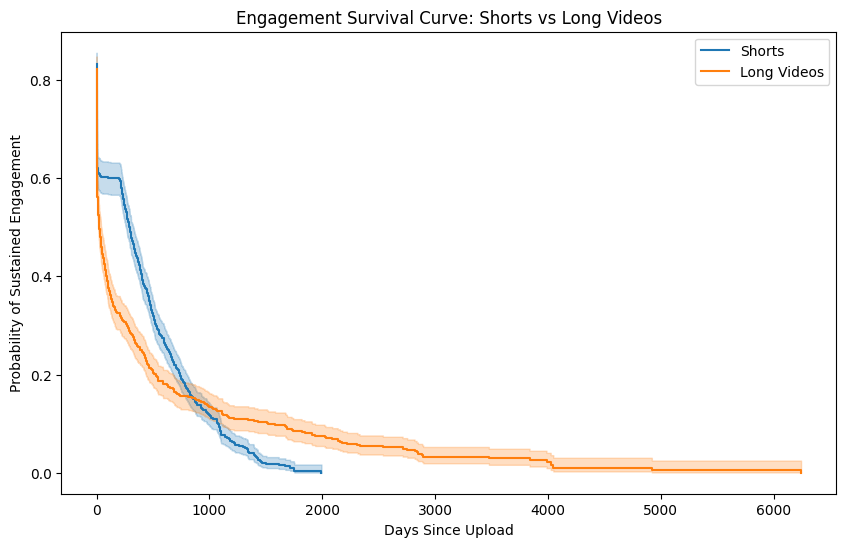


================ MEDIAN SURVIVAL TIME ================

Shorts median survival time: 293.0
Long videos median survival time: 24.0

================ LOG-RANK TEST ================

Test statistic: 5.5117
p-value: 0.018889

Conclusion: Significant difference in survival curves


In [ ]:
# "survival time" = days since upload
# Event = engagement drops below threshold

df["engagement"] = (
    df["likes"] + df["comments"] + 0.01 * df["views"]
)

df["engagement_norm"] = df.groupby("video_type")["engagement"].transform(
    lambda x: x / x.max()
)

threshold = 0.2

df["event"] = (df["engagement_norm"] < threshold).astype(int)

df["time"] = df["days_since_upload"]


# KAPLAN-MEIER FITTING


kmf_short = KaplanMeierFitter()
kmf_long = KaplanMeierFitter()

# Fit models
kmf_short.fit(
    durations=shorts["time"],
    event_observed=shorts["event"],
    label="Shorts"
)

kmf_long.fit(
    durations=longs["time"],
    event_observed=longs["event"],
    label="Long Videos"
)


# PLOT SURVIVAL CURVES


plt.figure(figsize=(10,6))

kmf_short.plot_survival_function()
kmf_long.plot_survival_function()

plt.title("Engagement Survival Curve: Shorts vs Long Videos")
plt.xlabel("Days Since Upload")
plt.ylabel("Probability of Sustained Engagement")

plt.show()


# MEDIAN SURVIVAL TIME


print("\n================ MEDIAN SURVIVAL TIME ================\n")

print("Shorts median survival time:",
      kmf_short.median_survival_time_)

print("Long videos median survival time:",
      kmf_long.median_survival_time_)


# LOG-RANK TEST (STATISTICAL COMPARISON)


results = logrank_test(
    shorts["time"],
    longs["time"],
    event_observed_A=shorts["event"],
    event_observed_B=longs["event"]
)

print("\n================ LOG-RANK TEST ================\n")
print(f"Test statistic: {results.test_statistic:.4f}")
print(f"p-value: {results.p_value:.6f}")

if results.p_value < 0.05:
    print("\nConclusion: Significant difference in survival curves")
else:
    print("\nConclusion: No significant difference")



================ COX MODEL SUMMARY ================



<lifelines.CoxPHFitter: fitted with 1576 total observations, 91 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1576
number of events observed = 1485
   partial log-likelihood = -9331.59
         time fit was run = 2026-05-21 16:10:23 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
video_type_encoded  0.06      1.06      0.06           -0.06            0.17                0.94                1.19
duration_seconds    0.00      1.00      0.00            0.00            0.00                1.00                1.00
likes              -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
comments           -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
upload_hour        -0.00      1.00      0.00           -0.01            0.01                0.99                1.01

                    cmp to      z      p  -log2(p)
covariate                                         
video_type_encoded    0.00   0.97   0.33      1.60
duration_seconds      0.00   4.13 <0.005     14.78
likes                 0.00 -10.78 <0.005     87.52
comments              0.00  -0.62   0.53      0.91
upload_hour           0.00  -0.61   0.54      0.88
---
Concordance = 0.71
Partial AIC = 18673.18
log-likelihood ratio test = 401.84 on 5 df
-log2(p) of ll-ratio test = 278.79


================ HAZARD RATIOS ================

covariate
video_type_encoded    1.059262
duration_seconds      1.000027
likes                 0.999999
comments              0.999996
upload_hour           0.997332
Name: coef, dtype: float64

================ INTERPRETATION ================


Cox Proportional Hazards Model estimates how
video characteristics affect engagement decay risk.

Hazard Ratio Interpretation:
- HR > 1 : higher risk of engagement decay
- HR < 1 : lower risk of engagement decay

Key Variable:
- video_type_encoded:
    1 = Shorts
    0 = Long Videos

If HR for Shorts > 1:
- Shorts lose engagement faster.

If HR for Shorts < 1:
- Shorts retain engagement longer.



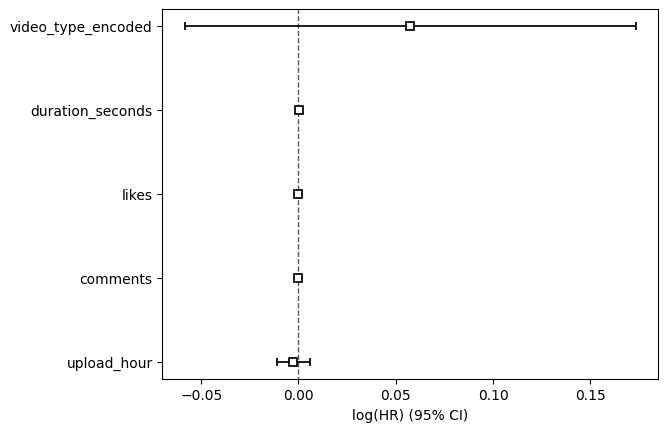

In [ ]:
from lifelines import CoxPHFitter

df["engagement"] = (
    df["likes"] + df["comments"] + 0.01 * df["views"]
)

df["engagement_norm"] = df.groupby("video_type")["engagement"].transform(
    lambda x: x / x.max()
)

# Event: engagement drops below threshold
threshold = 0.2

df["event"] = (
    df["engagement_norm"] < threshold
).astype(int)

# Survival time
df["time"] = df["days_since_upload"]

# Encode video type
# Short = 1, Long = 0
df["video_type_encoded"] = (
    df["video_type"] == "Short"
).astype(int)


cox_data = df[[
    "time",
    "event",
    "video_type_encoded",
    "duration_seconds",
    "likes",
    "comments",
    "upload_hour"
]]

# =========================================================
# 4. FIT COX MODEL
# =========================================================

cph = CoxPHFitter()

cph.fit(
    cox_data,
    duration_col="time",
    event_col="event"
)

# =========================================================
# 5. MODEL SUMMARY
# =========================================================

print("\n================ COX MODEL SUMMARY ================\n")

cph.print_summary()

# =========================================================
# 6. HAZARD RATIOS
# =========================================================

print("\n================ HAZARD RATIOS ================\n")

hazard_ratios = np.exp(cph.params_)

print(hazard_ratios)

# =========================================================
# 7. PLOT COEFFICIENTS
# =========================================================

cph.plot()

# =========================================================
# 8. INTERPRETATION
# =========================================================

print("\n================ INTERPRETATION ================\n")

print("""
Cox Proportional Hazards Model estimates how
video characteristics affect engagement decay risk.

Hazard Ratio Interpretation:
- HR > 1 : higher risk of engagement decay
- HR < 1 : lower risk of engagement decay

Key Variable:
- video_type_encoded:
    1 = Shorts
    0 = Long Videos

If HR for Shorts > 1:
- Shorts lose engagement faster.

If HR for Shorts < 1:
- Shorts retain engagement longer.
""")